# EDA for startup classification
# Goal: understand the business data, target distribution, and feature quality before training.


## Target column: `status`

The target column is `status`. It describes the company outcome that we want the model to predict: `operating`, `acquired`, `closed`, or `ipo`.

We choose `status` because it is the business outcome in this project. The other columns describe each company and are possible input features. We must keep `status` separate from the features so the model does not see the answer during training.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")


def resolve_data_path() -> Path:
    search_roots = []
    current = Path.cwd().resolve()
    search_roots.extend([current, *current.parents])

    for base in search_roots:
        for candidate in [
            base / "src" / "data" / "companies.csv",
            base / "src" / "companies.csv",
            base / "data" / "companies.csv",
            base / "companies.csv",
        ]:
            if candidate.exists():
                return candidate

    raise FileNotFoundError(
        "Dataset not found. Checked under the current working directory and its parent folders."
    )


DATA_PATH = resolve_data_path()
print(f"Using dataset: {DATA_PATH}")


Using dataset: /home/chandan/Work/ANN_RiceClassification_Using_Machine-Learning/src/data/companies.csv


In [4]:
DATA_PATH = resolve_data_path()

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (196553, 44)


,id,Unnamed: 0.1,entity_type,entity_id,parent_id,name,normalized_name,permalink,category_code,status,...,first_milestone_at,last_milestone_at,milestones,relationships,created_by,created_at,updated_at,lat,lng,ROI
0,c:1,0,Company,1,NaN,Wetpaint,wetpaint,/company/wetpaint,web,operating,...,2010-09-05,2013-09-18,5.0,17.0,initial-importer,2007-05-25 06:51:27,2013-04-13 03:29:00,47.606209,-122.332071,15.5
1,c:10,1,Company,10,NaN,Flektor,flektor,/company/flektor,games_video,acquired,...,NaN,NaN,NaN,6.0,initial-importer,2007-05-31 21:11:51,2008-05-23 23:23:14,34.021122,-118.396467,NaN
2,c:100,2,Company,100,NaN,There,there,/company/there,games_video,acquired,...,2003-02-01,2011-09-23,4.0,12.0,initial-importer,2007-08-06 23:52:45,2013-11-04 02:09:48,37.562992,-122.325525,NaN
3,c:10000,3,Company,10000,NaN,MYWEBBO,mywebbo,/company/mywebbo,network_hosting,operating,...,NaN,NaN,NaN,NaN,NaN,2008-08-24 16:51:57,2008-09-06 14:19:18,NaN,NaN,NaN
4,c:10001,4,Company,10001,NaN,THE Movie Streamer,the movie streamer,/company/the-movie-streamer,games_video,operating,...,NaN,NaN,NaN,NaN,NaN,2008-08-24 17:10:34,2008-09-06 14:19:18,NaN,NaN,NaN


In [5]:
print(df.info())
print("\nNull values per column:")
print(df.isna().sum().sort_values(ascending=False).head(20))


<class 'pandas.DataFrame'>
RangeIndex: 196553 entries, 0 to 196552
Data columns (total 44 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   196553 non-null  str    
 1   Unnamed: 0.1         196553 non-null  int64  
 2   entity_type          196553 non-null  str    
 3   entity_id            196553 non-null  int64  
 4   parent_id            0 non-null       float64
 5   name                 196530 non-null  str    
 6   normalized_name      196527 non-null  str    
 7   permalink            196553 non-null  str    
 8   category_code        123186 non-null  str    
 9   status               196553 non-null  str    
 10  founded_at           91227 non-null   str    
 11  closed_at            2620 non-null    str    
 12  domain               126545 non-null  str    
 13  homepage_url         126545 non-null  str    
 14  twitter_username     80591 non-null   str    
 15  logo_url             110110 

In [6]:
TARGET_COLUMN = "status"
print(df[TARGET_COLUMN].value_counts(dropna=False).head(10))

# Keep only the classes we want to classify
valid_statuses = ["operating", "acquired", "closed", "ipo"]
df = df[df[TARGET_COLUMN].isin(valid_statuses)].copy()
df[TARGET_COLUMN] = df[TARGET_COLUMN].str.lower().str.strip()
print(f"Filtered dataset shape: {df.shape}")
print(df[TARGET_COLUMN].value_counts())


status
operating    183441
acquired       9394
closed         2584
ipo            1134
Name: count, dtype: int64
Filtered dataset shape: (196553, 44)
status
operating    183441
acquired       9394
closed         2584
ipo            1134
Name: count, dtype: int64


In [7]:
NON_FEATURE_COLUMNS = [
    "id", "Unnamed: 0.1", "entity_type", "entity_id", "parent_id", "name",
    "normalized_name", "permalink", "domain", "homepage_url", "twitter_username",
    "logo_url", "logo_width", "logo_height", "short_description", "description",
    "overview", "tag_list", "created_by", "created_at", "updated_at",
    "first_investment_at", "last_investment_at", "first_funding_at", "last_funding_at",
    "first_milestone_at", "last_milestone_at", "created_by"
]

FEATURE_COLUMNS = [col for col in df.columns if col not in NON_FEATURE_COLUMNS + [TARGET_COLUMN]]
print(f"Feature count: {len(FEATURE_COLUMNS)}")
print(FEATURE_COLUMNS[:20])


Feature count: 16
['category_code', 'founded_at', 'closed_at', 'country_code', 'state_code', 'city', 'region', 'investment_rounds', 'invested_companies', 'funding_rounds', 'funding_total_usd', 'milestones', 'relationships', 'lat', 'lng', 'ROI']


In [8]:
# Keep only complete rows for the first clean pass
clean_df = df[FEATURE_COLUMNS + [TARGET_COLUMN]].copy()
clean_df = clean_df.drop_duplicates().reset_index(drop=True)
print(f"Cleaned shape: {clean_df.shape}")
print(clean_df.isna().sum().sort_values(ascending=False).head(10))


Cleaned shape: (101677, 17)
ROI                   100951
invested_companies    100221
investment_rounds     100221
closed_at              99058
funding_total_usd      73855
funding_rounds         70202
milestones             52945
state_code             52772
relationships          33130
lng                    20994
dtype: int64


Numeric columns: 9
Categorical columns: 8
['category_code', 'founded_at', 'closed_at', 'country_code', 'state_code', 'city', 'region', 'status']


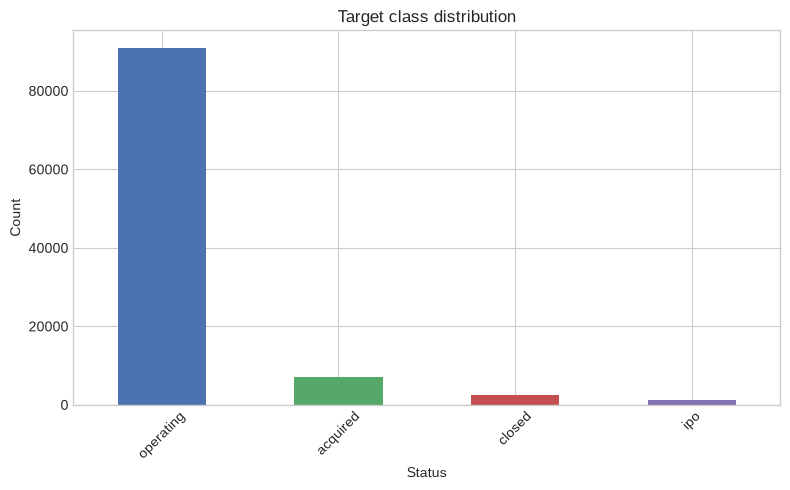

In [9]:
num_cols = clean_df.select_dtypes(include=["number"]).columns
cat_cols = clean_df.select_dtypes(exclude=["number"]).columns

print(f"Numeric columns: {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")
print(list(cat_cols[:10]))

# Class balance plot
counts = clean_df[TARGET_COLUMN].value_counts()
plt.figure(figsize=(8, 5))
counts.plot(kind="bar", color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
plt.title("Target class distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


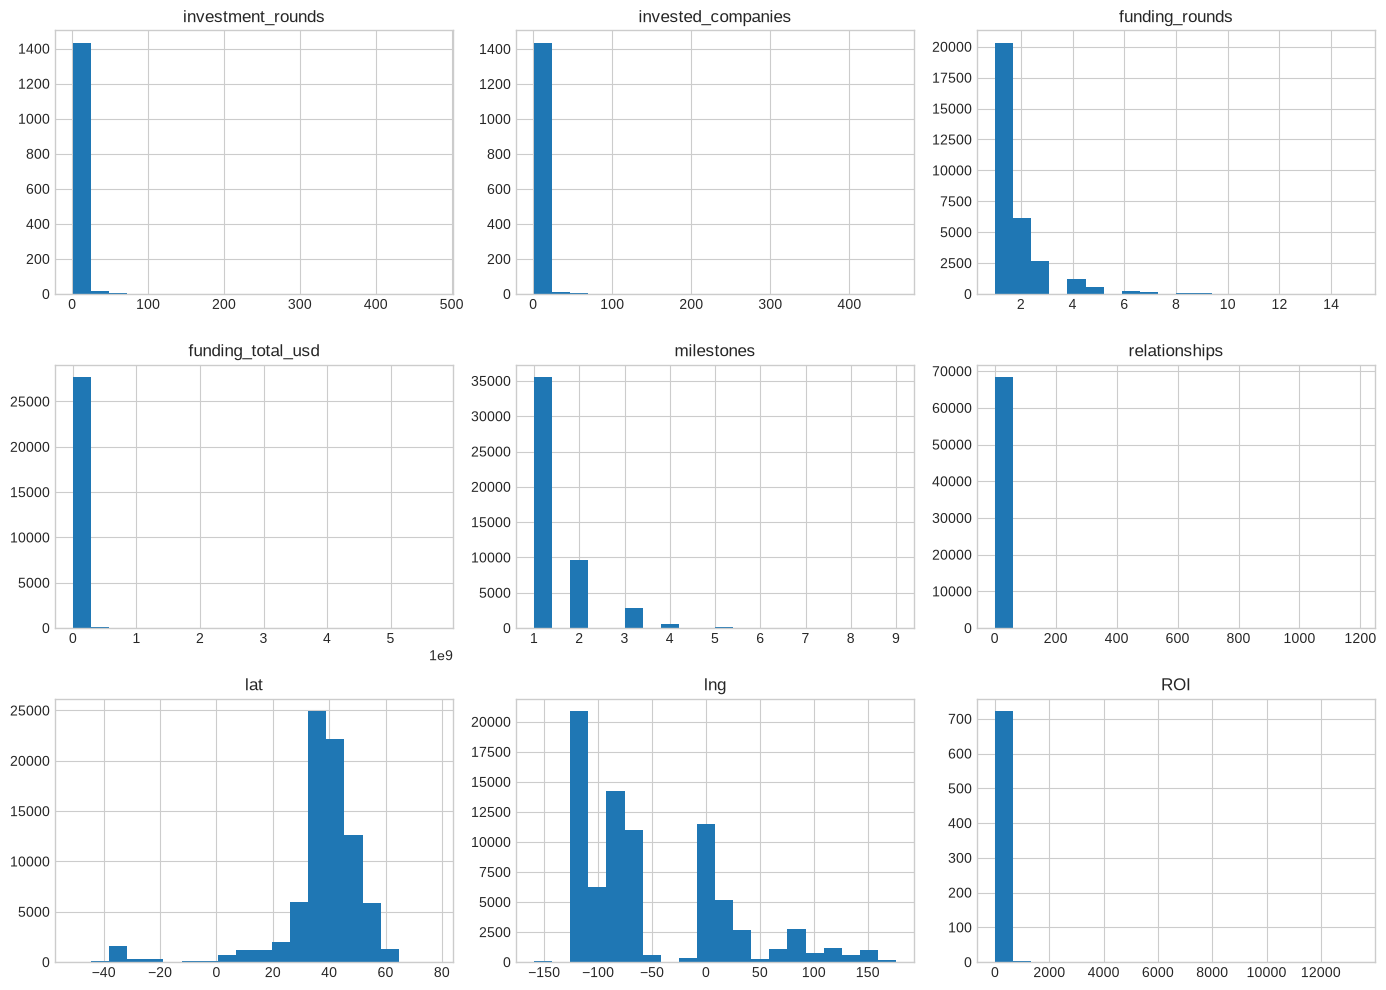

In [10]:
# Quick overview of numeric feature distributions
if len(num_cols) > 0:
    sample_numeric = clean_df[num_cols].select_dtypes(include=["number"]).dropna(axis=1, how="all")
    sample_numeric.hist(figsize=(14, 10), bins=20)
    plt.tight_layout()
    plt.show()


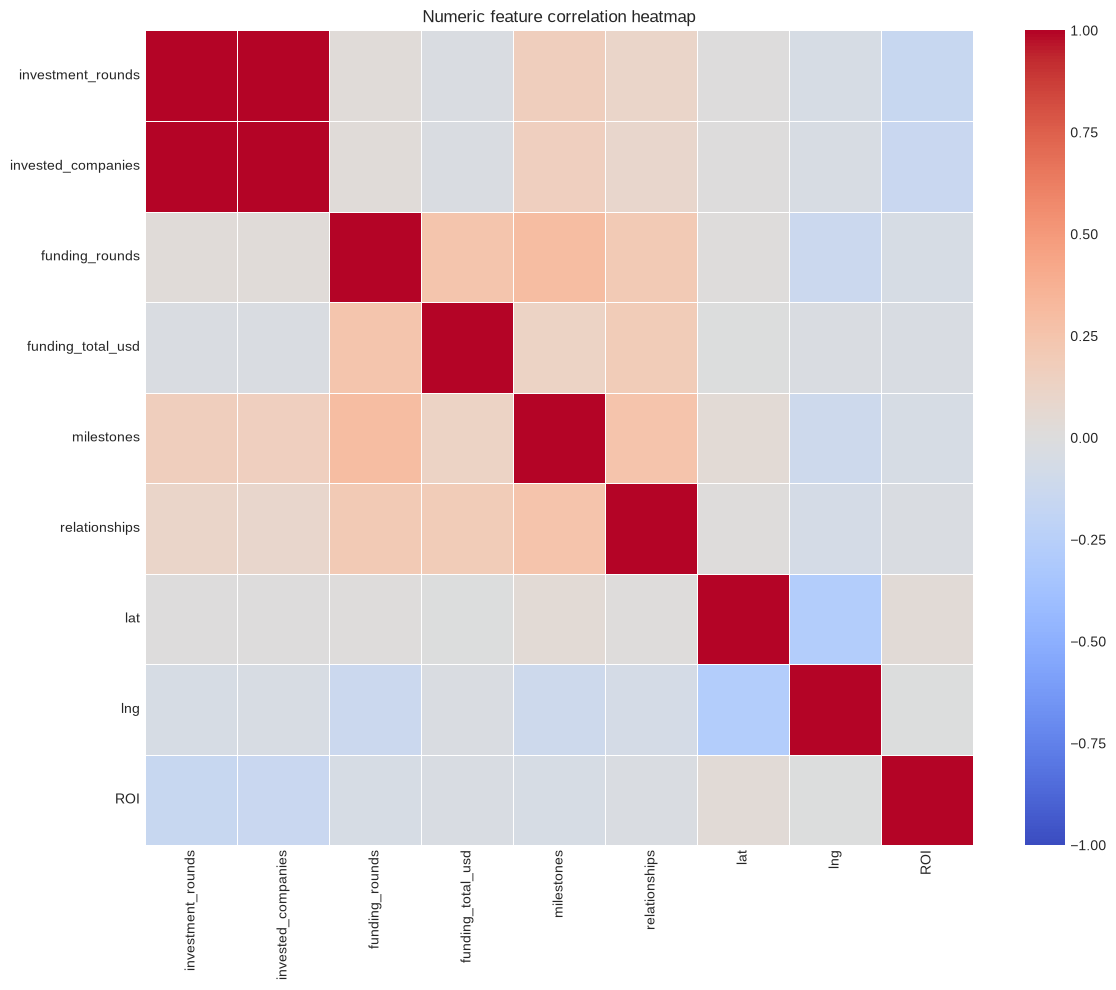

In [11]:
# Correlation heatmap for numeric features
if len(num_cols) > 0:
    corr = clean_df[num_cols].corr(numeric_only=True)
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, annot=False, linewidths=0.5)
    plt.title("Numeric feature correlation heatmap")
    plt.tight_layout()
    plt.show()


### Missing values, dates, and outlier review
This section adds the final EDA polish: missing-value strategy, date handling, categorical review, and outlier screening before modeling.

In [12]:
# Missing value strategy
missing_summary = clean_df.isna().sum().sort_values(ascending=False)
print(missing_summary.head(15))

# Date columns review
for col in [c for c in clean_df.columns if 'date' in c.lower() or 'at' in c.lower()]:
    non_null = clean_df[col].notna().sum()
    print(f"{col}: {non_null} non-null values")

# Categorical cardinality review
for col in cat_cols:
    unique_count = clean_df[col].nunique(dropna=True)
    if unique_count > 20:
        print(f"High-cardinality categorical feature: {col} ({unique_count} unique values)")

# Outlier review on numeric fields
numeric_for_outliers = clean_df[num_cols].select_dtypes(include=['number'])
q1 = numeric_for_outliers.quantile(0.25)
q3 = numeric_for_outliers.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_counts = ((numeric_for_outliers < lower_bound) | (numeric_for_outliers > upper_bound)).sum()
print("\nPotential outlier counts by numeric feature (IQR rule):")
print(outlier_counts[outlier_counts > 0].sort_values(ascending=False).head(10))


ROI                   100951
invested_companies    100221
investment_rounds     100221
closed_at              99058
funding_total_usd      73855
funding_rounds         70202
milestones             52945
state_code             52772
relationships          33130
lng                    20994
lat                    20994
city                   20956
founded_at             20120
country_code           17428
category_code           6454
dtype: int64
category_code: 95223 non-null values
founded_at: 81557 non-null values
closed_at: 2619 non-null values
state_code: 48905 non-null values
relationships: 68547 non-null values
lat: 80683 non-null values
status: 101677 non-null values
High-cardinality categorical feature: category_code (42 unique values)
High-cardinality categorical feature: founded_at (6156 unique values)
High-cardinality categorical feature: closed_at (925 unique values)
High-cardinality categorical feature: country_code (175 unique values)
High-cardinality categorical feature: st

In [ ]:
# Final EDA conclusion
print("Missing value strategy:")
print("- Drop high-noise identifier / metadata columns.")
print("- Keep the main target status column.")
print("- For model-ready features, use median imputation for numeric columns and frequent-category imputation for categorical columns.")
print("- Convert date columns to temporal features only when needed for the final pipeline.")
print("- Review high-cardinality categorical columns and consider grouping or encoding them carefully.")
print("- For outliers, inspect distribution and decide between clipping or robust transformations before modeling.")

print("\nEDA conclusion:")
print("The dataset is large and structurally clean enough for modeling, with four target classes and a moderate class imbalance. "
      "The main challenge is a large number of missing values in metadata and date-related fields, which should be handled inside the preprocessing pipeline rather than by deleting data blindly.")

print("\nRecommended next step:")
print("Build a preprocessing pipeline with imputation, one-hot encoding for categorical variables, and a model comparison step using train/validation/test splits.")


{'rows': 101677, 'columns': 17, 'target_distribution': {'operating': 90847, 'acquired': 7117, 'closed': 2583, 'ipo': 1130}, 'missing_values': 790301}
